In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

Based on:
https://github.com/mazoku/mrf_segmentation/blob/master/mrfsegmentation/markov_random_field.py


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image shape: (512, 540)
K-means label distribution: {np.int32(0): np.int64(109570), np.int32(1): np.int64(76048), np.int32(2): np.int64(8084), np.int32(3): np.int64(50618), np.int32(4): np.int64(32160)}
ICM iteration 1: label distribution {np.int32(0): np.int64(106953), np.int32(1): np.int64(76282), np.int32(2): np.int64(10403), np.int32(3): np.int64(51858), np.int32(4): np.int64(30984)}
ICM iteration 1 completed
ICM iteration 2: label distribution {np.int32(0): np.int64(106522), np.int32(1): np.int64(76343), np.int32(2): np.int64(12036), np.int32(3): np.int64(51212), np.int32(4): np.int64(30367)}
ICM iteration 2 completed
ICM iteration 3: label distribution {np.int32(0): np.int64(106389), np.int32(1): np.int64(77185), np.int32(2): np.int64(12979), np.int32(3): np.int64(50693), np.int32(4): np.int64(29234)}
ICM iteration 3 completed
ICM iteration 4: label dis

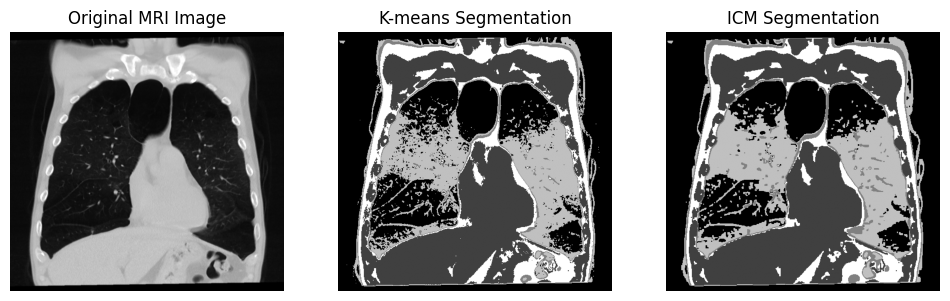

In [ ]:
import numpy as np
import cv2
from sklearn.cluster import KMeans
import tifffile as tiff
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

workpath = '/content/drive/MyDrive/DigitalImageProcessing/'

k=5

def load_tif_image(path):
    # Use cv2 to read PNG images as grayscale
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image at {path}")
    # Normalize if needed and ensure uint8 type
    if img.dtype != np.uint8:
        # Scale to 0-255 if image has higher bit depth
        if img.max() > 0:
            img = (img / img.max()) * 255
        img = img.astype(np.uint8)
    return img

def kmeans_segmentation(img, k):
    # Reshape image to (num_pixels, num_features)
    flat_img = img.reshape(-1, 1)
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(flat_img)
    unique, counts = np.unique(labels, return_counts=True)
    print("K-means label distribution:", dict(zip(unique, counts)))
    return labels.reshape(img.shape[:2]), kmeans.cluster_centers_

def local_energy(pixel, label, means, variances, neighbors, beta):
    # Data term: negative log-likelihood for univariate Gaussian
    mu = means[label]
    var = variances[label]
    data_term = 0.5 * np.log(2 * np.pi * var) + 0.5 * ((pixel - mu) ** 2) / var # Eq. (1.25)

    # Potts model smoothness term (sum over neighbors)
    sum_neighbors = beta * sum(label != n for n in neighbors) # Eq. (1.27)
    return data_term + sum_neighbors


def estimate_gaussian_parameters(img, labels, k):
    # Estimate mean and variance of each label/class
    means = np.zeros(k)
    variances = np.zeros(k)
    for idx in range(k):
        pixels = img[labels == idx]
        if len(pixels) > 0:
            means[idx] = pixels.mean()
            variances[idx] = pixels.var() + 1e-6  # avoid zero variance
        else:
            means[idx] = 0
            variances[idx] = 1e6
    return means, variances


def icm_segmentation(img, init_labels, k, max_iter=10, beta=2.0):
    seg = init_labels.copy()
    rows, cols = seg.shape
    for it in range(max_iter):
        means, variances = estimate_gaussian_parameters(img, seg, k)
        updated = False
        for i in range(rows):
            for j in range(cols):
                pixel = img[i, j]
                # 4-neighborhood
                neighbors = []
                for ii, jj in [(i-1,j), (i+1,j), (i,j-1), (i,j+1)]:
                    if 0 <= ii < rows and 0 <= jj < cols:
                        neighbors.append(seg[ii, jj])
                # Compute local energy for each label
                energies = [
                    local_energy(pixel, lbl, means, variances, neighbors, beta)
                    for lbl in range(k)
                ]
                min_label = np.argmin(energies)
                if seg[i, j] != min_label:
                    seg[i, j] = min_label
                    updated = True
        unique, counts = np.unique(seg, return_counts=True)
        print(f"ICM iteration {it+1}: label distribution {dict(zip(unique, counts))}")
        print(f"ICM iteration {it+1} completed")
        if not updated:
            print("Converged.")
            break
    return seg

def visualize_results(img, kmeans_labels, icm_labels):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title('Original MRI Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(kmeans_labels, cmap='gray')
    plt.title('K-means Segmentation')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(icm_labels, cmap='gray')
    plt.title('ICM Segmentation')
    plt.axis('off')
    plt.show()

if __name__ == '__main__':
    img_path = workpath + 'Data/lung.png'
    # Remove [:,:,0] as load_tif_image will now return a 2D grayscale image
    img = load_tif_image(img_path)
    print(f"Image shape: {img.shape}")

    kmeans_labels, _ = kmeans_segmentation(img, k=k)
    icm_labels = icm_segmentation(img, kmeans_labels, k, max_iter=10, beta=2.0)
    visualize_results(img, kmeans_labels, icm_labels)
